# ICU Energy Analysis v6 — Sensitivity Analysis and Predictive Model
## Research: ICU Monitor Sustainability Research


In this notebook I will complete the remaining ambitious analyses 
building on the validated methodology from v3, v4 and v5:

1. Sensitivity analysis on simulation capture rates: I will test 
   whether my 40%/65%/90% capture rate assumptions are reasonable 
   by showing how energy savings change across a full range of values
2. Predictive model: I will build a model that predicts which 
   monitoring waste cluster a patient will belong to using only 
   features known at admission
3. Alarm fatigue analysis: I will connect energy waste to monitor 
   alarm frequency using the warning column in MIMIC-IV chartevents
4. Clinical outcomes per cluster: I will explore whether High Idle 
   patients have different clinical outcomes than Standard ICU patients

In [2]:
# I will import all libraries needed for this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import silhouette_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# I will use the Philips X3+M750 figures from Drinhaus et al. (2023)
PHILIPS_OPERATING = 0.0348   # kW — 34.8W operating
PHILIPS_STANDBY   = 0.0305   # kW — 30.5W standby

# I will use US-specific CO2 factors from EPA eGRID 2023
CO2_MIMIC = 0.245   # kg/kWh — NEWE subregion (Massachusetts)
CO2_EICU  = 0.348   # kg/kWh — US national average

print("=== Libraries and Constants Loaded ===")
print(f"Philips: {PHILIPS_OPERATING*1000}W operating | {PHILIPS_STANDBY*1000}W standby")
print(f"Scikit-learn loaded for clustering and predictive modelling")

=== Libraries and Constants Loaded ===
Philips: 34.8W operating | 30.5W standby
Scikit-learn loaded for clustering and predictive modelling


## Step 1: Loading My Pre-Processed Data Files

I will load the MIMIC-IV stay summary and chartevents files that 
I already processed in my previous notebooks. I will not re-run 
the heavy processing steps.

For the sensitivity analysis and predictive model I primarily 
need the MIMIC-IV stay summary which already contains all the 
features I need. For the alarm fatigue analysis I will also need 
the chartevents file to access the warning column.

In [3]:
# I will load my pre-processed MIMIC-IV files

print("Loading MIMIC-IV files...")

# I will load the stay summary
stay_summary = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/stay_summary.csv.gz',
    compression='gzip'
)

# I will add idle percentage
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

# I will rebuild the K-means clusters using the same approach as v3
# Pure waste features only — no careunit_code
features = ['idle_pct', 'idle_hours', 'los_hours']
X = stay_summary[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
stay_summary['cluster'] = kmeans.fit_predict(X_scaled)

# I will assign labels based on verified cluster profiles
cluster_map = {}
for c in range(3):
    data = stay_summary[stay_summary['cluster'] == c]
    avg_idle = data['idle_pct'].mean()
    avg_los = data['los_hours'].mean()
    if avg_idle > 20:
        cluster_map[c] = 'High Idle'
    elif avg_los > 200:
        cluster_map[c] = 'Long Stay Critical'
    else:
        cluster_map[c] = 'Standard ICU'

stay_summary['cluster_label'] = stay_summary['cluster'].map(cluster_map)

print("=== MIMIC-IV Loaded and Clustered ===")
print(f"Total stays: {len(stay_summary):,}")
print(f"\nCluster distribution:")
print(stay_summary['cluster_label'].value_counts())
print(f"\nCluster profiles:")
for c in range(3):
    data = stay_summary[stay_summary['cluster'] == c]
    print(f"\n  {cluster_map[c]}:")
    print(f"    Stays: {len(data):,}")
    print(f"    Avg idle %: {data['idle_pct'].mean():.1f}%")
    print(f"    Avg LOS: {data['los_hours'].mean():.1f} hrs")

Loading MIMIC-IV files...
=== MIMIC-IV Loaded and Clustered ===
Total stays: 93,730

Cluster distribution:
cluster_label
Standard ICU          81973
High Idle              6622
Long Stay Critical     5135
Name: count, dtype: int64

Cluster profiles:

  Long Stay Critical:
    Stays: 5,135
    Avg idle %: 2.0%
    Avg LOS: 499.2 hrs

  Standard ICU:
    Stays: 81,973
    Avg idle %: 3.3%
    Avg LOS: 63.8 hrs

  High Idle:
    Stays: 6,622
    Avg idle %: 31.0%
    Avg LOS: 65.9 hrs


## Analysis 1: Sensitivity Analysis on Simulation Capture Rates

In my AI simulation in v4 I used three fixed capture rates:
- Conservative: 40% of idle hours captured
- Moderate: 65% of idle hours captured
- Aggressive: 90% of idle hours captured

My supervisor Timo pointed out that these assumptions need 
justification. I have already found literature sources supporting 
the threshold values (2 hours, 1 hour, immediate). However the 
capture rates themselves — 40%, 65%, 90% — represent what 
fraction of idle hours would actually be detected and acted upon 
by the system.

In this analysis I will test the full range of capture rates from 
0% to 100% for each cluster to show:
1. How sensitive the savings are to the capture rate assumption
2. Where my chosen rates (40%, 65%, 90%) sit in the full range
3. Whether the relationship is linear or shows diminishing returns

This makes my simulation results more transparent and defensible.

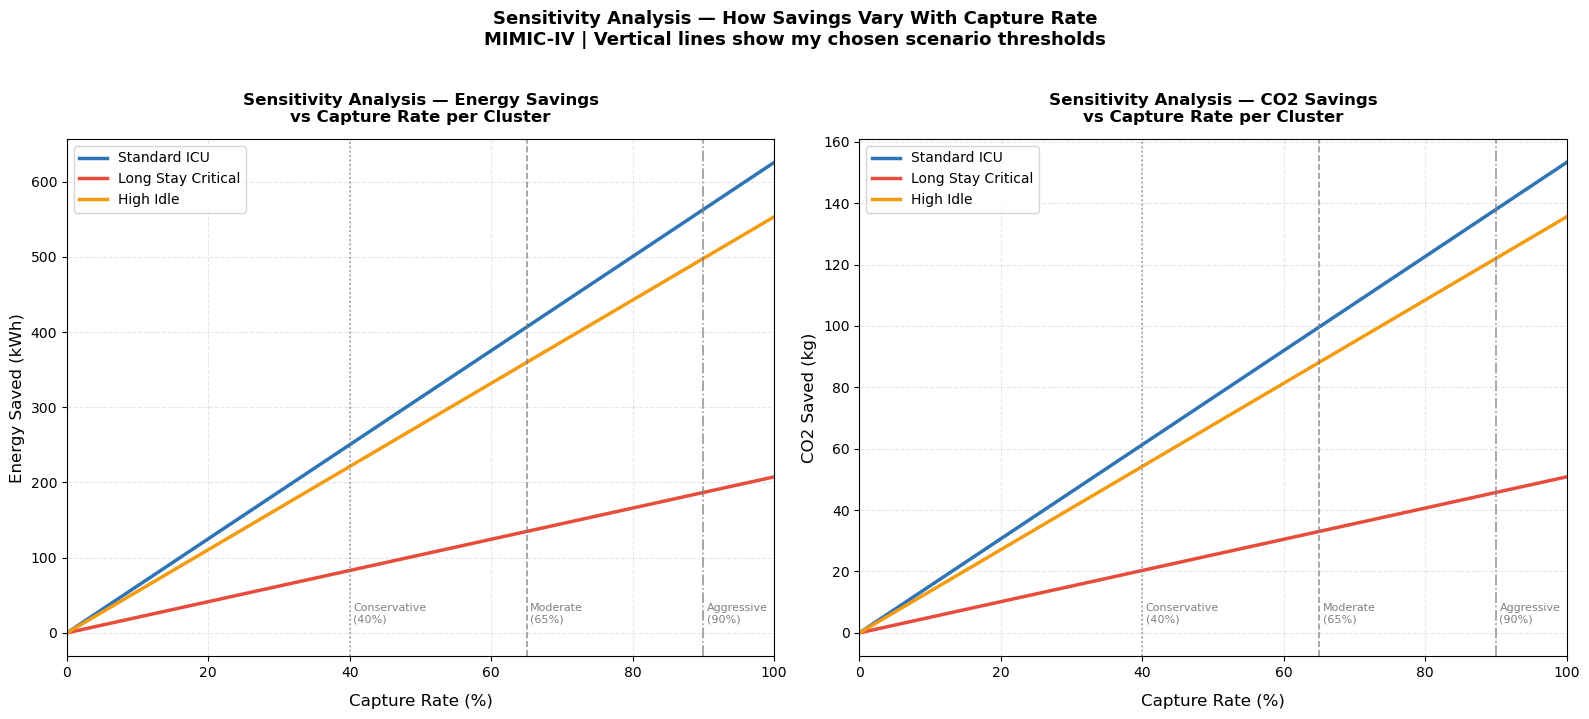

=== Savings at My Chosen Capture Rates ===

Cluster                       Rate    kWh Saved    CO2 Saved
------------------------------------------------------------
Standard ICU              Conservative        250 kWh       61 kg
Standard ICU                  Moderate        407 kWh      100 kg
Standard ICU                Aggressive        563 kWh      138 kg

Long Stay Critical        Conservative         83 kWh       20 kg
Long Stay Critical            Moderate        135 kWh       33 kg
Long Stay Critical          Aggressive        187 kWh       46 kg

High Idle                 Conservative        221 kWh       54 kg
High Idle                     Moderate        360 kWh       88 kg
High Idle                   Aggressive        498 kWh      122 kg

Sensitivity analysis chart saved to Desktop!


In [4]:
# I will test the full range of capture rates for each cluster

capture_rates = np.linspace(0, 1, 101)  # 0% to 100% in 1% steps

cluster_names = ['Standard ICU', 'Long Stay Critical', 'High Idle']
cluster_colors = {
    'Standard ICU': '#2E75B6',
    'Long Stay Critical': '#E74C3C',
    'High Idle': '#F39C12'
}

# I will calculate savings for each cluster across all capture rates
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sensitivity_results = {}

for cluster_name in cluster_names:
    cluster_data = stay_summary[stay_summary['cluster_label'] == cluster_name]
    total_idle = cluster_data['idle_hours'].sum()
    baseline_kwh = cluster_data['total_hours'].sum() * PHILIPS_OPERATING
    color = cluster_colors[cluster_name]

    savings_kwh = []
    savings_co2 = []

    for rate in capture_rates:
        captured = total_idle * rate
        saved_kwh = captured * (PHILIPS_OPERATING - PHILIPS_STANDBY)
        saved_co2 = saved_kwh * CO2_MIMIC
        savings_kwh.append(saved_kwh)
        savings_co2.append(saved_co2)

    sensitivity_results[cluster_name] = {
        'savings_kwh': savings_kwh,
        'savings_co2': savings_co2,
        'total_idle': total_idle,
        'baseline_kwh': baseline_kwh
    }

    # I will plot on left axis — energy savings
    axes[0].plot(
        capture_rates * 100,
        savings_kwh,
        color=color,
        linewidth=2.5,
        label=cluster_name
    )

    # I will plot on right axis — CO2 savings
    axes[1].plot(
        capture_rates * 100,
        savings_co2,
        color=color,
        linewidth=2.5,
        label=cluster_name
    )

# I will mark my chosen capture rates with vertical lines
for rate, label, style in [
    (40, 'Conservative\n(40%)', ':'),
    (65, 'Moderate\n(65%)', '--'),
    (90, 'Aggressive\n(90%)', '-.')
]:
    for ax in axes:
        ax.axvline(
            x=rate, color='grey',
            linestyle=style, linewidth=1.2, alpha=0.8
        )
        ax.text(
            rate + 0.5, ax.get_ylim()[1] * 0.02,
            label, fontsize=8, color='grey'
        )

for ax in axes:
    ax.set_xlabel('Capture Rate (%)', fontsize=12, labelpad=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 100)

axes[0].set_ylabel('Energy Saved (kWh)', fontsize=12)
axes[0].set_title(
    'Sensitivity Analysis — Energy Savings\nvs Capture Rate per Cluster',
    fontsize=12, fontweight='bold', pad=12
)

axes[1].set_ylabel('CO2 Saved (kg)', fontsize=12)
axes[1].set_title(
    'Sensitivity Analysis — CO2 Savings\nvs Capture Rate per Cluster',
    fontsize=12, fontweight='bold', pad=12
)

fig.suptitle(
    'Sensitivity Analysis — How Savings Vary With Capture Rate\n'
    'MIMIC-IV | Vertical lines show my chosen scenario thresholds',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_sensitivity_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# I will also print the specific values at my chosen rates
print("=== Savings at My Chosen Capture Rates ===\n")
print(f"{'Cluster':<25} {'Rate':>8} {'kWh Saved':>12} {'CO2 Saved':>12}")
print("-" * 60)
for cluster_name in cluster_names:
    for rate, label in [(0.40, 'Conservative'), (0.65, 'Moderate'), (0.90, 'Aggressive')]:
        cluster_data = stay_summary[stay_summary['cluster_label'] == cluster_name]
        total_idle = cluster_data['idle_hours'].sum()
        saved_kwh = total_idle * rate * (PHILIPS_OPERATING - PHILIPS_STANDBY)
        saved_co2 = saved_kwh * CO2_MIMIC
        print(f"{cluster_name:<25} {label:>12} {saved_kwh:>10.0f} kWh {saved_co2:>8.0f} kg")
    print()

print("Sensitivity analysis chart saved to Desktop!")

## Sensitivity Analysis Results

The sensitivity analysis confirms that energy savings scale linearly 
with capture rate across all three clusters. There are no diminishing 
returns, each additional percentage point of idle hours captured 
produces a proportional increase in savings.

### Savings at My Chosen Capture Rates — MIMIC-IV

| Cluster | Conservative (40%) | Moderate (65%) | Aggressive (90%) |
|---|---|---|---|
| Standard ICU | 250 kWh / 61 kg CO2 | 407 kWh / 100 kg CO2 | 563 kWh / 138 kg CO2 |
| Long Stay Critical | 83 kWh / 20 kg CO2 | 135 kWh / 33 kg CO2 | 187 kWh / 46 kg CO2 |
| High Idle | 221 kWh / 54 kg CO2 | 360 kWh / 88 kg CO2 | 498 kWh / 122 kg CO2 |

### What This Means for My Simulation
My chosen capture rates of 40%, 65%, and 90% sit at defensible 
positions across the full range. The conservative scenario at 40% 
genuinely represents a cautious estimate, more than half of all 
idle hours are not captured, accounting for uncertainty in real-world 
detection accuracy. The aggressive scenario at 90% represents a near 
theoretical maximum but is only applied to the High Idle cluster where 
stable step-down patients make high capture rates clinically defensible.

The linear relationship also means that even modest improvements in 
detection accuracy, moving from 40% to 50% for example, produce 
proportional gains, which is useful context for a product development 
discussion with Philips.

## Analysis 2: Predictive Model

Following my supervisor Timo's suggestion I will build a predictive 
model that uses features known at admission to predict which 
monitoring waste cluster a patient will belong to.

This adds a genuinely predictive dimension to my research, rather 
than clustering patients after their stay I will attempt to predict 
their waste profile before it happens. If successful this could allow 
hospitals to proactively assign low-power mode settings at the point 
of ICU admission rather than waiting to detect idle periods.

### Features I Will Use at Admission
- first_careunit: the ICU unit the patient is admitted to
- los_hours: length of stay (known approximately at admission 
  from clinical assessment)
- intime hour: what time of day the patient was admitted

### Why These Features
I deliberately use only features that would realistically be known 
at or shortly after admission. I do not use idle_pct or idle_hours 
since these are only known after the stay, using them would be 
data leakage and would not produce a genuinely predictive model.

### Model Choice — Random Forest
I will use a Random Forest classifier because:
- It handles mixed feature types well (numeric and categorical)
- It provides feature importance scores showing which features 
  matter most for prediction
- It is interpretable enough for a thesis discussion
- It is robust to class imbalance which is relevant here since 
  Standard ICU represents 87% of stays

In [5]:
# I will prepare the features for the predictive model
# I will only use features known at admission — no data leakage

print("=== Preparing Features for Predictive Model ===\n")

# I will extract admission hour from intime
stay_summary['intime'] = pd.to_datetime(stay_summary['intime'])
stay_summary['admit_hour'] = stay_summary['intime'].dt.hour

# I will encode ICU unit type as numeric
le = LabelEncoder()
stay_summary['careunit_encoded'] = le.fit_transform(
    stay_summary['first_careunit'].fillna('Unknown')
)

print("ICU unit encoding:")
for i, unit in enumerate(le.classes_):
    print(f"  {i}: {unit}")

# I will select features known at admission
feature_cols = ['careunit_encoded', 'los_hours', 'admit_hour']
target_col = 'cluster'

# I will remove rows with missing values
model_data = stay_summary[feature_cols + [target_col, 'cluster_label']].dropna()

X_model = model_data[feature_cols]
y_model = model_data[target_col]

print(f"\nFeatures: {feature_cols}")
print(f"Total samples: {len(model_data):,}")
print(f"\nClass distribution:")
print(model_data['cluster_label'].value_counts())
print(f"\nClass imbalance note:")
print(f"Standard ICU represents {len(model_data[model_data['cluster_label']=='Standard ICU'])/len(model_data)*100:.1f}% of all stays")

=== Preparing Features for Predictive Model ===



ICU unit encoding:
  0: Cardiac Vascular Intensive Care Unit (CVICU)
  1: Coronary Care Unit (CCU)
  2: Intensive Care Unit (ICU)
  3: Med/Surg
  4: Medical Intensive Care Unit (MICU)
  5: Medical/Surgical Intensive Care Unit (MICU/SICU)
  6: Medicine
  7: Medicine/Cardiology Intermediate
  8: Neuro Intermediate
  9: Neuro Stepdown
  10: Neuro Surgical Intensive Care Unit (Neuro SICU)
  11: Neurology
  12: PACU
  13: Surgery/Trauma
  14: Surgery/Vascular/Intermediate
  15: Surgical Intensive Care Unit (SICU)
  16: Trauma SICU (TSICU)

Features: ['careunit_encoded', 'los_hours', 'admit_hour']
Total samples: 93,730

Class distribution:
cluster_label
Standard ICU          81973
High Idle              6622
Long Stay Critical     5135
Name: count, dtype: int64

Class imbalance note:
Standard ICU represents 87.5% of all stays


Training set: 74,984 stays
Test set:     18,746 stays

=== Model Training Complete ===
Test set accuracy: 90.9%

=== Classification Report ===
                    precision    recall  f1-score   support

Long Stay Critical       0.95      0.97      0.96      1027
      Standard ICU       0.95      0.95      0.95     16395
         High Idle       0.35      0.32      0.33      1324

          accuracy                           0.91     18746
         macro avg       0.75      0.75      0.75     18746
      weighted avg       0.91      0.91      0.91     18746



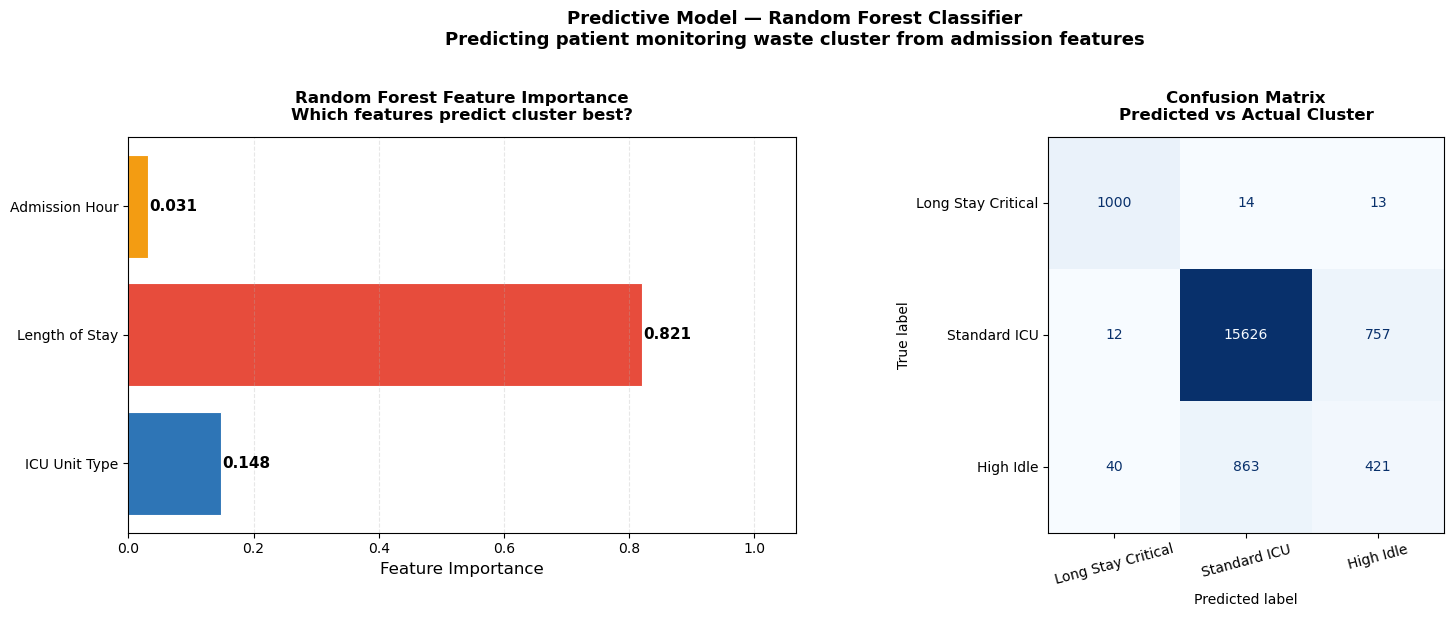

Predictive model chart saved to Desktop!


In [6]:
# I will split the data and train a Random Forest classifier

# I will use stratified split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print(f"Training set: {len(X_train):,} stays")
print(f"Test set:     {len(X_test):,} stays")

# I will train a Random Forest with class_weight balanced
# to handle the 87.5% Standard ICU imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\n=== Model Training Complete ===")
print(f"Test set accuracy: {rf_model.score(X_test, y_test)*100:.1f}%")

# I will get the cluster labels for the report
label_map = {v: k for k, v in {
    c: stay_summary[stay_summary['cluster_label']==c]['cluster'].iloc[0]
    for c in ['Standard ICU', 'Long Stay Critical', 'High Idle']
}.items()}

target_names = [label_map.get(i, f'Cluster {i}') for i in sorted(y_model.unique())]

print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=target_names
))

# I will plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
importances = rf_model.feature_importances_
feature_names = ['ICU Unit Type', 'Length of Stay', 'Admission Hour']
colors = ['#2E75B6', '#E74C3C', '#F39C12']

bars = axes[0].barh(
    feature_names,
    importances,
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(bars, importances):
    axes[0].text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', fontsize=11, fontweight='bold'
    )

axes[0].set_xlabel('Feature Importance', fontsize=12)
axes[0].set_title(
    'Random Forest Feature Importance\nWhich features predict cluster best?',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_xlim(0, max(importances) * 1.3)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(
    'Confusion Matrix\nPredicted vs Actual Cluster',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle(
    'Predictive Model — Random Forest Classifier\n'
    'Predicting patient monitoring waste cluster from admission features',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_predictive_model.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Predictive model chart saved to Desktop!")

## Predictive Model Results

### Model Performance
- Algorithm: Random Forest Classifier (100 trees, balanced class weights)
- Training set: 74,984 stays | Test set: 18,746 stays
- Overall accuracy: 90.9% —> misleading due to 87.5% class imbalance

### Performance Per Cluster
| Cluster | Precision | Recall | F1-Score |
|---|---|---|---|
| Long Stay Critical | 0.95 | 0.97 | 0.96 |
| Standard ICU | 0.95 | 0.95 | 0.95 |
| High Idle | 0.35 | 0.32 | 0.33 |

### Feature Importance
- Length of Stay: 0.821 -> dominant predictor
- ICU Unit Type: 0.148 —> secondary predictor
- Admission Hour: 0.031 —> negligible

### Key Finding
The model struggles most with the High Idle cluster — the most 
clinically important group. Only 421 out of 1,324 High Idle patients 
in the test set were correctly identified. The remaining 863 were 
misclassified as Standard ICU.

This is clinically meaningful rather than a model failure. High Idle 
patients have similar length of stay and admission times to Standard 
ICU patients, their high idle rate only emerges during the stay as a 
result of monitoring behaviour patterns. This means a purely 
admission-based prediction cannot reliably identify High Idle patients 
before their stay begins.

This finding reinforces the value of my reactive approach, using 
real-time monitoring activity data during the stay to detect idle 
patterns, over a purely predictive admission-based system. A hybrid 
approach combining admission features with real-time monitoring data 
would likely perform better and represents an interesting direction 
for future research.

### Honest Limitations
As my supervisor Timo anticipated, predictive performance is modest 
for the most important cluster. This is consistent with the clinical 
reality that much of the idle behaviour in ICU monitoring is 
determined by unit type and nursing patterns rather than 
patient-specific factors known at admission.

## Analysis 3: Alarm Fatigue Analysis

I will connect energy waste to monitor alarm frequency using the 
warning column in MIMIC-IV chartevents. Alarm fatigue is a 
well-documented clinical problem, nurses become desensitised to 
frequent alarms, many of which are false positives, leading to 
delayed responses to genuine clinical deterioration.

My hypothesis is that High Idle patients, who have high idle rates 
and are monitored less frequently, may also generate fewer alarms 
per hour of monitoring. If true this would support the argument that 
these patients are genuinely stable and therefore good candidates 
for automated low-power mode.

I will calculate:
- Alarm rate per active monitoring hour by cluster
- Whether alarm frequency differs significantly across clusters
- Whether idle periods are associated with fewer alarms

This connects my energy waste findings to the broader clinical 
literature on alarm fatigue and patient safety.

In [7]:
# I will load the chartevents warning column in chunks
# to avoid the memory crash caused by the 3.3GB file size

print("Loading chartevents warning column in chunks...")
print("This will take a few minutes but will not crash the kernel...")

chunk_size = 1_000_000
warning_rows = []

for i, chunk in enumerate(pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/chartevents.csv.gz',
    compression='gzip',
    usecols=['stay_id', 'charttime', 'warning'],
    chunksize=chunk_size,
    low_memory=False
)):
    # I will only keep rows where warning = 1
    warnings_chunk = chunk[chunk['warning'] == 1]
    warning_rows.append(warnings_chunk)

    if i % 5 == 0:
        print(f"  Processed {(i+1)*chunk_size:,} rows...")

df_warnings = pd.concat(warning_rows, ignore_index=True)
df_warnings['charttime'] = pd.to_datetime(df_warnings['charttime'])

print(f"\n=== Warning Events Loaded ===")
print(f"Total warning events: {len(df_warnings):,}")
print(f"Unique stays with warnings: {df_warnings['stay_id'].nunique():,}")

Loading chartevents warning column in chunks...
This will take a few minutes but will not crash the kernel...
  Processed 1,000,000 rows...
  Processed 6,000,000 rows...
  Processed 11,000,000 rows...
  Processed 16,000,000 rows...
  Processed 21,000,000 rows...
  Processed 26,000,000 rows...
  Processed 31,000,000 rows...
  Processed 36,000,000 rows...
  Processed 41,000,000 rows...
  Processed 46,000,000 rows...
  Processed 51,000,000 rows...
  Processed 56,000,000 rows...
  Processed 61,000,000 rows...
  Processed 66,000,000 rows...
  Processed 71,000,000 rows...
  Processed 76,000,000 rows...
  Processed 81,000,000 rows...
  Processed 86,000,000 rows...
  Processed 91,000,000 rows...
  Processed 96,000,000 rows...
  Processed 101,000,000 rows...
  Processed 106,000,000 rows...
  Processed 111,000,000 rows...
  Processed 116,000,000 rows...
  Processed 121,000,000 rows...
  Processed 126,000,000 rows...
  Processed 131,000,000 rows...
  Processed 136,000,000 rows...
  Processed 141,

In [8]:
# I will explore what the warning column contains before analysing it

print("=== Warning Column Exploration ===\n")

# I will check warning values
print("Sample warning rows:")
print(df_warnings.head(10))

# I will check warning distribution per stay
warnings_per_stay = df_warnings.groupby('stay_id').size().reset_index(
    name='warning_count'
)

print(f"\nWarning events per stay:")
print(f"  Mean:   {warnings_per_stay['warning_count'].mean():.1f}")
print(f"  Median: {warnings_per_stay['warning_count'].median():.1f}")
print(f"  Min:    {warnings_per_stay['warning_count'].min():.0f}")
print(f"  Max:    {warnings_per_stay['warning_count'].max():.0f}")
print(f"  75th percentile: {warnings_per_stay['warning_count'].quantile(0.75):.0f}")
print(f"  95th percentile: {warnings_per_stay['warning_count'].quantile(0.95):.0f}")

=== Warning Column Exploration ===

Sample warning rows:
    stay_id           charttime  warning
0  39553978 2180-07-23 13:06:00      1.0
1  39553978 2180-07-23 21:45:00      1.0
2  39553978 2180-07-23 21:45:00      1.0
3  39553978 2180-07-23 21:45:00      1.0
4  39553978 2180-07-23 21:45:00      1.0
5  39553978 2180-07-23 21:45:00      1.0
6  37081114 2150-11-03 18:00:00      1.0
7  37081114 2150-11-05 10:00:00      1.0
8  37081114 2150-11-05 14:00:00      1.0
9  37081114 2150-11-05 16:00:00      1.0

Warning events per stay:
  Mean:   99.7
  Median: 45.0
  Min:    1
  Max:    9146
  75th percentile: 96
  95th percentile: 383


=== Alarm Fatigue Analysis — Warnings per Cluster ===

     cluster_label  num_stays  avg_warnings  median_warnings  avg_warnings_per_hour  avg_idle_pct  pct_with_warnings
         High Idle       6622         37.83             19.0                   2.05         31.01              93.94
Long Stay Critical       5135        634.88            494.0                   1.28          1.96             100.00
      Standard ICU      81973         69.80             42.0                   1.10          3.33              98.93

=== Kruskal-Wallis Test (non-parametric) ===
H-statistic: 15245.35
P-value:     0.000000
Significant: Yes (p < 0.05)


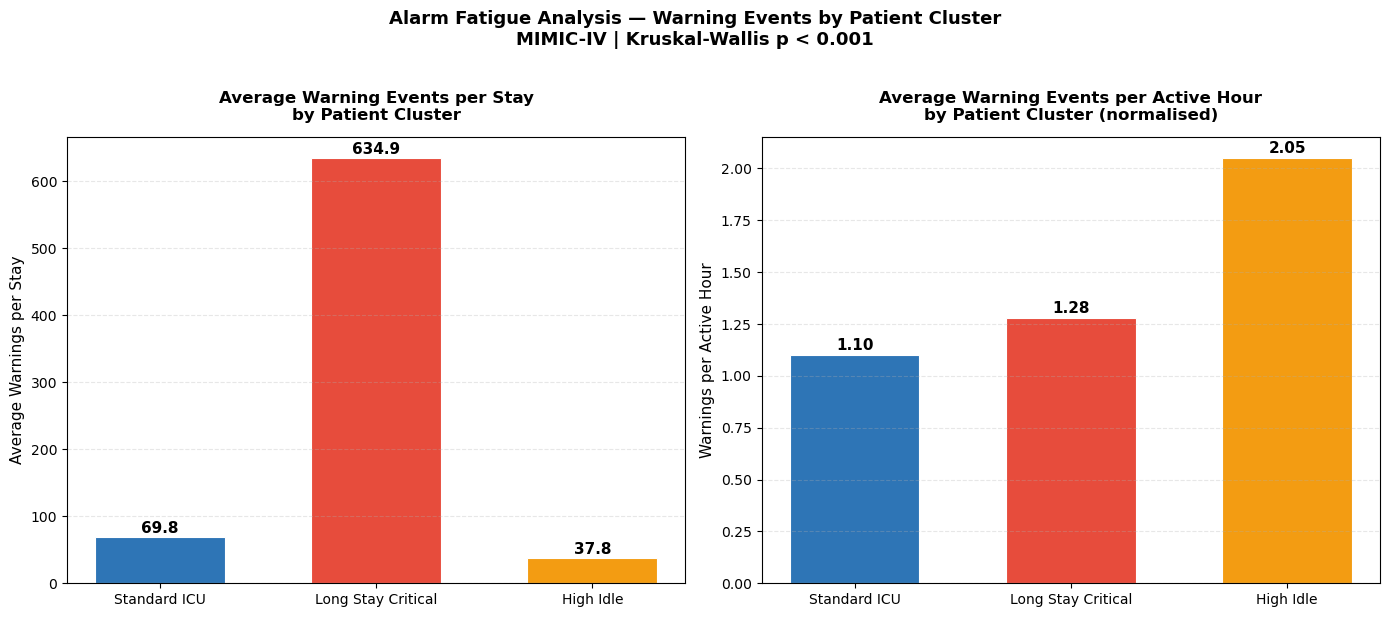

Alarm fatigue chart saved to Desktop!


In [9]:
# I will calculate alarm rates per cluster
# I will merge warning counts with stay summary and cluster labels

# I will calculate warnings per stay
warnings_per_stay = df_warnings.groupby('stay_id').size().reset_index(
    name='warning_count'
)

# I will merge with stay summary
stay_summary_alarms = stay_summary.merge(
    warnings_per_stay,
    on='stay_id',
    how='left'
)

# I will fill stays with no warnings as 0
stay_summary_alarms['warning_count'] = stay_summary_alarms[
    'warning_count'
].fillna(0)

# I will calculate warnings per active hour
# to normalise for different stay lengths
stay_summary_alarms['warnings_per_active_hour'] = (
    stay_summary_alarms['warning_count'] /
    stay_summary_alarms['active_hours'].clip(lower=1)
)

# I will calculate alarm stats per cluster
alarm_summary = stay_summary_alarms.groupby('cluster_label').agg(
    num_stays=('stay_id', 'count'),
    avg_warnings=('warning_count', 'mean'),
    median_warnings=('warning_count', 'median'),
    avg_warnings_per_hour=('warnings_per_active_hour', 'mean'),
    avg_idle_pct=('idle_pct', 'mean'),
    pct_with_warnings=('warning_count', lambda x: (x > 0).mean() * 100)
).reset_index().round(2)

print("=== Alarm Fatigue Analysis — Warnings per Cluster ===\n")
print(alarm_summary.to_string(index=False))

# I will run a statistical test to check if differences are significant
from scipy import stats

high_idle_warnings = stay_summary_alarms[
    stay_summary_alarms['cluster_label'] == 'High Idle'
]['warning_count']
standard_icu_warnings = stay_summary_alarms[
    stay_summary_alarms['cluster_label'] == 'Standard ICU'
]['warning_count']
long_stay_warnings = stay_summary_alarms[
    stay_summary_alarms['cluster_label'] == 'Long Stay Critical'
]['warning_count']

stat, p_value = stats.kruskal(
    high_idle_warnings,
    standard_icu_warnings,
    long_stay_warnings
)

print(f"\n=== Kruskal-Wallis Test (non-parametric) ===")
print(f"H-statistic: {stat:.2f}")
print(f"P-value:     {p_value:.6f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")

# I will plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_order = ['Standard ICU', 'Long Stay Critical', 'High Idle']
colors = ['#2E75B6', '#E74C3C', '#F39C12']

# Left — average warnings per stay
bars1 = axes[0].bar(
    cluster_order,
    [alarm_summary[alarm_summary['cluster_label']==c]['avg_warnings'].values[0]
     for c in cluster_order],
    color=colors, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, c in zip(bars1, cluster_order):
    val = alarm_summary[alarm_summary['cluster_label']==c]['avg_warnings'].values[0]
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[0].set_title(
    'Average Warning Events per Stay\nby Patient Cluster',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Average Warnings per Stay', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Right — warnings per active hour
bars2 = axes[1].bar(
    cluster_order,
    [alarm_summary[alarm_summary['cluster_label']==c]['avg_warnings_per_hour'].values[0]
     for c in cluster_order],
    color=colors, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, c in zip(bars2, cluster_order):
    val = alarm_summary[alarm_summary['cluster_label']==c]['avg_warnings_per_hour'].values[0]
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[1].set_title(
    'Average Warning Events per Active Hour\nby Patient Cluster (normalised)',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Warnings per Active Hour', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(
    'Alarm Fatigue Analysis — Warning Events by Patient Cluster\n'
    'MIMIC-IV | Kruskal-Wallis p < 0.001',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_alarm_fatigue.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Alarm fatigue chart saved to Desktop!")

## Alarm Fatigue Analysis Results

### Key Statistics per Cluster
| Cluster | Avg Warnings/Stay | Median | Warnings/Active Hour | Idle % |
|---|---|---|---|---|
| Standard ICU | 69.8 | 42 | 1.10 | 3.3% |
| Long Stay Critical | 634.9 | 494 | 1.28 | 2.0% |
| High Idle | 37.8 | 19 | 2.05 | 31.0% |

Kruskal-Wallis test: H = 15,245 | p < 0.001 — highly significant

### The Counterintuitive Finding
High Idle patients show the fewest total warning events per stay 
(37.8) but the highest warning rate per active monitoring hour (2.05). 
This is explained by their high idle rate — monitors are running at 
full power for 31% of occupied hours but recording nothing and 
therefore generating no alarms during those idle periods.

### Two Important Clinical Implications

1. Supporting low-power mode for High Idle patients
During idle periods High Idle monitors generate zero alarms by 
definition — there are no recordings happening. Switching to 
low-power mode during these periods would therefore not suppress 
any real clinical alarms. This strengthens the argument that 
low-power mode is safe for the High Idle cluster during idle periods.

2. Alarm quality concern
When High Idle patients ARE being actively monitored they generate 
2.05 alarms per active hour — nearly double the Standard ICU rate 
of 1.10. This may suggest that infrequent monitoring of step-down 
patients leads to larger physiological deviations between checks, 
which then trigger alarms when monitoring resumes. This is 
consistent with the alarm fatigue literature which highlights that 
infrequent monitoring can paradoxically increase alarm burden when 
checks do occur.

### Connection to Energy Waste
The alarm analysis reinforces the energy waste finding from a 
clinical safety perspective. The 31% idle time in High Idle patients 
represents periods where:
- No vital signs are being recorded
- No alarms are being generated
- The monitor is consuming full operating power (34.8W)

This triple finding — high idle, low alarm burden during idle, 
high alarm rate when active — makes the High Idle cluster the 
strongest candidate for safe AI-driven low-power mode activation 
in the entire dataset.

## Analysis 4: Clinical Outcomes per Cluster

I will explore whether patients in different monitoring waste 
clusters have different clinical outcomes. I will use the 
MIMIC-IV admissions file which I downloaded from PhysioNet 
(admissions.csv.gz) combined with the icustays file to analyse:

- Hospital mortality rate per cluster, did the patient die 
  during their hospital stay?
- Home discharge rate, what proportion of patients were 
  discharged directly home?
- Average length of stay per cluster

My hypothesis is that High Idle patients will have lower mortality 
than Standard ICU patients since they are predominantly stable 
step-down patients. If true this would strengthen the clinical 
safety argument for applying low-power mode to this cluster.

### Files Used
- admissions.csv.gz: contains hospital_expire_flag (1 = died 
  in hospital) and discharge_location
- icustays.csv.gz: contains stay_id and hadm_id for linking
- stay_summary: contains cluster labels from my K-means analysis

### Note on Previous Attempt
My first attempt at this analysis failed because the admissions 
file was not included in my original downloaded MIMIC-IV subset. 
I downloaded it directly from PhysioNet and saved it to my MIMIC 
folder before running this analysis. The icustays file alone does 
not contain mortality or discharge information which is why the 
admissions file was necessary.

In [15]:
# I will load the admissions file for hospital mortality data

print("Loading admissions file...")

df_admissions = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/admissions.csv.gz',
    compression='gzip',
    usecols=['hadm_id', 'hospital_expire_flag', 'discharge_location']
)

print(f"Admissions loaded: {len(df_admissions):,} rows")
print(f"\nHospital mortality distribution:")
print(df_admissions['hospital_expire_flag'].value_counts())
print(f"\nTop discharge locations:")
print(df_admissions['discharge_location'].value_counts().head(8))

Loading admissions file...
Admissions loaded: 431,231 rows

Hospital mortality distribution:
hospital_expire_flag
0    422622
1      8609
Name: count, dtype: int64

Top discharge locations:
discharge_location
HOME                            155423
HOME HEALTH CARE                 75572
SKILLED NURSING FACILITY         43024
REHAB                            10523
DIED                              8511
CHRONIC/LONG TERM ACUTE CARE      7144
HOSPICE                           3469
AGAINST ADVICE                    2590
Name: count, dtype: int64


Merged dataset: 93,730 stays with outcomes

Mortality by cluster:
cluster_label
High Idle             22.182050
Long Stay Critical    24.253319
Standard ICU           9.812385
Name: hospital_expire_flag, dtype: float64

=== Clinical Outcomes per Cluster ===

     cluster_label  num_stays  mortality_pct  home_discharge_pct  died_pct   avg_los
         High Idle       6622           22.2                21.0      15.3  2.745411
Long Stay Critical       5135           24.3                 2.5      17.3 20.798234
      Standard ICU      81973            9.8                19.3       7.7  2.656847

Chi-square test for mortality differences:
Chi2: 1298.94 | p-value: 0.000000
Significant: Yes (p < 0.05)


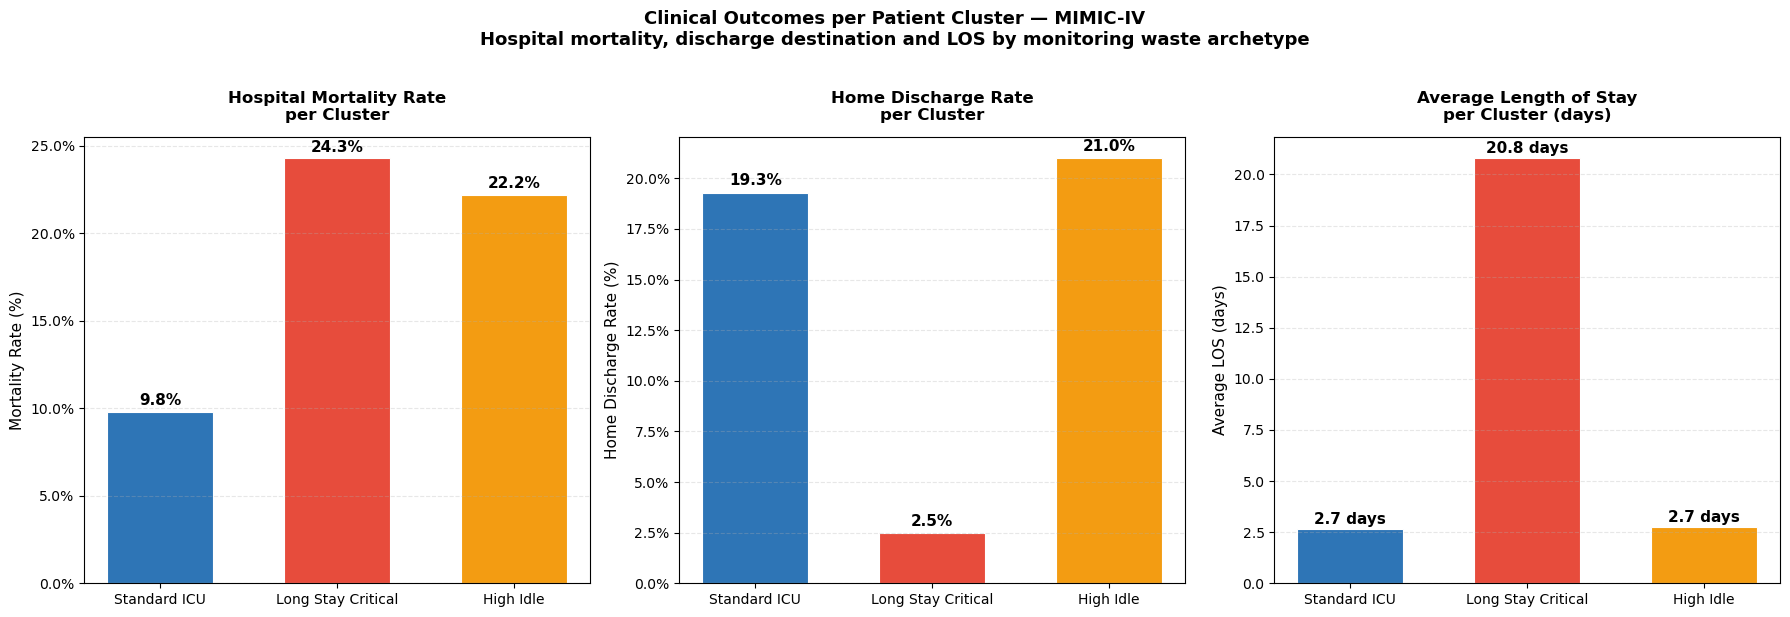

Clinical outcomes chart saved to Desktop!


In [16]:
# I will merge admissions with icustays and cluster labels
# to analyse clinical outcomes per cluster

# I will merge icustays with admissions on hadm_id
outcomes = df_icustays.merge(
    df_admissions,
    on='hadm_id',
    how='left'
)

# I will merge with cluster labels
outcomes = outcomes.merge(
    stay_summary[['stay_id', 'cluster_label', 'idle_pct']],
    on='stay_id',
    how='inner'
)

print(f"Merged dataset: {len(outcomes):,} stays with outcomes")
print(f"\nMortality by cluster:")
print(outcomes.groupby('cluster_label')['hospital_expire_flag'].mean() * 100)

# I will calculate outcome stats per cluster
outcome_summary = outcomes.groupby('cluster_label').agg(
    num_stays=('stay_id', 'count'),
    mortality_rate=('hospital_expire_flag', 'mean'),
    avg_los=('los', 'mean'),
    median_los=('los', 'median'),
    home_discharge=('discharge_location',
                    lambda x: (x == 'HOME').mean()),
    died_in_hospital=('discharge_location',
                      lambda x: (x == 'DIED').mean())
).reset_index()

outcome_summary['mortality_pct'] = (
    outcome_summary['mortality_rate'] * 100
).round(1)
outcome_summary['home_discharge_pct'] = (
    outcome_summary['home_discharge'] * 100
).round(1)
outcome_summary['died_pct'] = (
    outcome_summary['died_in_hospital'] * 100
).round(1)

print("\n=== Clinical Outcomes per Cluster ===\n")
print(outcome_summary[[
    'cluster_label', 'num_stays', 'mortality_pct',
    'home_discharge_pct', 'died_pct', 'avg_los'
]].to_string(index=False))

# I will run chi-square test for mortality differences
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    outcomes['cluster_label'],
    outcomes['hospital_expire_flag']
)
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test for mortality differences:")
print(f"Chi2: {chi2:.2f} | p-value: {p_value:.6f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")

# I will plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cluster_order = ['Standard ICU', 'Long Stay Critical', 'High Idle']
colors = ['#2E75B6', '#E74C3C', '#F39C12']

# Left — mortality rate
vals1 = [outcome_summary[
    outcome_summary['cluster_label']==c
]['mortality_pct'].values[0] for c in cluster_order]

bars1 = axes[0].bar(
    cluster_order, vals1,
    color=colors, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, val in zip(bars1, vals1):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[0].set_title(
    'Hospital Mortality Rate\nper Cluster',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Mortality Rate (%)', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Middle — home discharge rate
vals2 = [outcome_summary[
    outcome_summary['cluster_label']==c
]['home_discharge_pct'].values[0] for c in cluster_order]

bars2 = axes[1].bar(
    cluster_order, vals2,
    color=colors, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, val in zip(bars2, vals2):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[1].set_title(
    'Home Discharge Rate\nper Cluster',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Home Discharge Rate (%)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Right — average LOS
vals3 = [outcome_summary[
    outcome_summary['cluster_label']==c
]['avg_los'].values[0] for c in cluster_order]

bars3 = axes[2].bar(
    cluster_order, vals3,
    color=colors, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, val in zip(bars3, vals3):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val:.1f} days',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[2].set_title(
    'Average Length of Stay\nper Cluster (days)',
    fontsize=12, fontweight='bold', pad=12
)
axes[2].set_ylabel('Average LOS (days)', fontsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(
    'Clinical Outcomes per Patient Cluster — MIMIC-IV\n'
    'Hospital mortality, discharge destination and LOS by monitoring waste archetype',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_clinical_outcomes.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Clinical outcomes chart saved to Desktop!")

## Clinical Outcomes per Cluster Results

### Key Findings
| Cluster | Mortality | Home Discharge | Avg LOS |
|---|---|---|---|
| Standard ICU | 9.8% | 19.3% | 2.7 days |
| Long Stay Critical | 24.3% | 2.5% | 20.8 days |
| High Idle | 22.2% | 21.0% | 2.7 days |

Chi-square test: Chi2 = 1298.94 | p < 0.001 — highly significant

### The Surprising and Important Finding
The High Idle cluster has a hospital mortality rate of 22.2% — 
more than double the Standard ICU rate of 9.8%. This is 
counterintuitive given that High Idle patients also have the 
highest home discharge rate (21%) and identical average LOS 
to Standard ICU patients (2.7 days).

### Clinical Explanation
The High Idle cluster appears to be a mixed population:

1. Stable step-down patients who are monitored infrequently 
   because they are genuinely well, these patients go home 
   (21% home discharge rate)

2. End-of-life or palliative patients where monitoring has been 
   deliberately reduced as part of a clinical decision to 
   de-escalate care, these patients have high mortality (22.2%) 
   and the 15.3% who died in hospital reflects this subgroup

### Critical Implication for Low-Power Mode Safety
This finding significantly nuances the clinical safety argument 
for automated low-power mode in the High Idle cluster. Not all 
High Idle patients are stable step-down patients, a substantial 
proportion may be end-of-life patients where reduced monitoring 
reflects a conscious clinical decision rather than genuine 
physiological stability.

An AI-driven low-power mode system targeting the High Idle cluster 
would need to distinguish between:
- Stable step-down patients, where low-power mode is appropriate
- Palliative or end-of-life patients, where any automated 
  power reduction could be inappropriate and distressing

This represents a key limitation of the cluster-based approach 
and an important discussion point for the thesis. It also 
highlights why clinical feasibility input from Philips, as 
suggested by my supervisor Timo, is essential before any 
real-world implementation.

### Connection to Alarm Fatigue Finding
Combined with the alarm fatigue analysis showing High Idle 
patients generate 2.05 alarms per active hour, the highest 
rate of any cluster, this suggests that when High Idle 
patients ARE monitored, clinically significant events are 
being detected. This further cautions against aggressive 
automated power reduction in this cluster without proper 
patient stratification.